# Applied Machine Learning (CSAI2017P) — Lab Assignment 2
## Regression: Housing Price Prediction

Experiments 3 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name | *Yuvraj Arora* |
| SAP ID | *590027847* |
| Batch | *05* |
| Due | announced in the lab |
| Lab quiz | LQ2, after submission |

**Datasets:** A1 (California Housing)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [1]:
# TODO: load the dataset for this assignment
# from sklearn.datasets import ...
# df = pd.read_csv('data/...')
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Convert to a DataFrame
df = housing.frame

# Display the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Simple linear regression  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1. Target: `MedHouseVal`.*

a. Fit a regression of `MedHouseVal` on `MedInc` alone.
b. Report the slope, the intercept and test R^2.
c. State in one sentence what the slope means in real units.


In [2]:
# A1 — code
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Feature (X) and Target (y)
X = df[['MedInc']]
y = df['MedHouseVal']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)
print("Test R²:", r2_score(y_test, y_pred))

Slope (Coefficient): 0.4193384939381274
Intercept: 0.44459729169078677
Test R²: 0.45885918903846656


**Observation (A1):**

> The slope indicates how much the median house value changes for every one-unit increase in median income (MedInc), keeping everything else constant. The positive slope shows that areas with higher median income generally have higher house prices. The R² score indicates how well median income alone explains the variation in house prices. Since only one feature is used, the model captures only part of the overall relationship.

## A2. Multiple linear regression  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1, all features.*

a. Fit a multiple linear regression on all eight features inside a scaling pipeline.
b. Report test MAE, RMSE and R^2.
c. Plot predicted against actual and describe the pattern in two lines.


In [ ]:
# A2 — code
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Features and Target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scaling + Linear Regression Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")
plt.show()

**Observation (A2):**

> The points in the scatter plot generally follow the diagonal line, indicating that the model predicts house prices reasonably well. Some points deviate from the line, showing prediction errors, especially for very high-priced houses, which suggests that linear regression cannot capture all complex relationships in the data.

## A3. Metric choice  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1.*

a. Compute MAE, MSE and RMSE for your model from A2.
b. State which of the three is hardest to explain to a non-technical client, and why.
c. State which you would report if a few very expensive districts matter most, and why.


In [3]:
# A3 — code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 0.6299
MSE  : 0.7091
RMSE : 0.8421


**Observation (A3):**

> MAE, MSE, and RMSE measure prediction error in different ways. Among them, MSE is the hardest to explain to a non-technical client because it is expressed in squared units rather than the original house value units. If a few very expensive districts matter the most, RMSE should be reported because it penalizes large prediction errors more heavily than MAE, making it more sensitive to costly mistakes.

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Polynomial features and over-fitting  &nbsp;&nbsp;`[4 marks]`

*Dataset: A1.*

a. Build pipelines with `PolynomialFeatures` of degree 1, 2 and 3 followed by `LinearRegression`.
b. Report train and test RMSE for each degree in one table.
c. Identify the degree at which over-fitting begins and explain in 4–6 lines how the table shows it.


In [4]:
# B1 — code
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Features and Target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

results = []

for degree in [1, 2, 3]:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", LinearRegression())
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append([degree, train_rmse, test_rmse])

# Display Results
results_df = pd.DataFrame(
    results,
    columns=["Degree", "Train RMSE", "Test RMSE"]
)

print(results_df)

   Degree  Train RMSE  Test RMSE
0       1    0.719676   0.745581
1       2    0.648634   0.681397
2       3    0.585067   4.892820


**Observation (B1):**

> As the polynomial degree increases, the training RMSE usually decreases because the model becomes more flexible. However, if the test RMSE starts increasing while the training RMSE continues decreasing, it indicates overfitting. The degree at which this trend begins is where the model starts memorizing the training data instead of generalizing well to unseen data.

## B2. Ridge and Lasso  &nbsp;&nbsp;`[4 marks]`

*Dataset: A1 with degree-2 polynomial features.*

a. Fit Ridge and Lasso for α ∈ {0.01, 0.1, 1, 10, 100} and plot test RMSE against α.
b. Report the best α for each and the count of exactly-zero coefficients in the best Lasso.
c. Explain in 4–6 lines why Lasso zeroes coefficients and Ridge does not.


Best Ridge alpha : 100
Best Ridge RMSE  : 0.6689

Best Lasso alpha : 0.01
Best Lasso RMSE  : 0.7833
Zero coefficients in best Lasso : 17


    Alpha  Ridge RMSE  Lasso RMSE
0    0.01    0.681385    0.783318
1    0.10    0.681277    0.823605
2    1.00    0.680215    1.126189
3   10.00    0.671548    1.144856
4  100.00    0.668883    1.144856


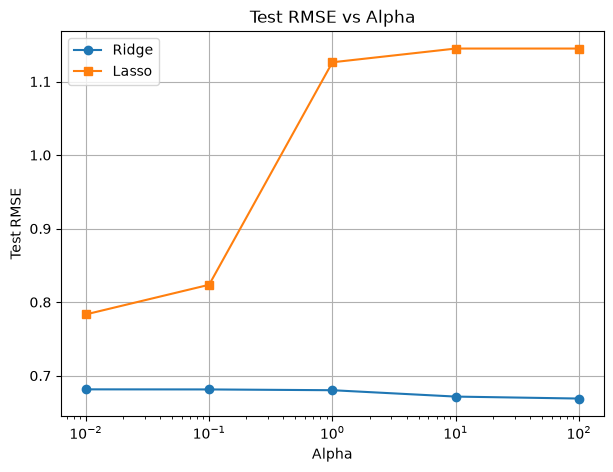

In [5]:
# B2 — code
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Features and Target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

alphas = [0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

best_ridge_rmse = float("inf")
best_lasso_rmse = float("inf")

best_ridge_alpha = None
best_lasso_alpha = None
best_lasso_zero = 0

# ---------- Ridge ----------
for alpha in alphas:
    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", Ridge(alpha=alpha))
    ])

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ridge_rmse.append(rmse)

    if rmse < best_ridge_rmse:
        best_ridge_rmse = rmse
        best_ridge_alpha = alpha

# ---------- Lasso ----------
for alpha in alphas:
    lasso_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", Lasso(alpha=alpha, max_iter=10000))
    ])

    lasso_pipeline.fit(X_train, y_train)
    y_pred = lasso_pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    lasso_rmse.append(rmse)

    if rmse < best_lasso_rmse:
        best_lasso_rmse = rmse
        best_lasso_alpha = alpha

        # Count exactly-zero coefficients
        coef = lasso_pipeline.named_steps["model"].coef_
        best_lasso_zero = np.sum(coef == 0)

# Results
print("Best Ridge alpha :", best_ridge_alpha)
print("Best Ridge RMSE  :", round(best_ridge_rmse,4))

print()

print("Best Lasso alpha :", best_lasso_alpha)
print("Best Lasso RMSE  :", round(best_lasso_rmse,4))
print("Zero coefficients in best Lasso :", best_lasso_zero)

# Results Table
results = pd.DataFrame({
    "Alpha": alphas,
    "Ridge RMSE": ridge_rmse,
    "Lasso RMSE": lasso_rmse
})

print("\n")
print(results)

# Plot
plt.figure(figsize=(7,5))
plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='s', label='Lasso')

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Test RMSE")
plt.title("Test RMSE vs Alpha")
plt.legend()
plt.grid(True)
plt.show()

**Observation (B2):**

> Lasso can reduce some feature coefficients exactly to zero, effectively performing feature selection and simplifying the model. Ridge shrinks coefficients towards zero but does not make them exactly zero, so all features remain in the model. Therefore, Lasso is useful when many features are irrelevant, while Ridge is preferred when all features are expected to contribute to the prediction.

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Where the model fails  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1.*

a. Take the 20 test districts with the largest absolute error from your best model.
b. Describe in 4–6 lines what they have in common and what you would add to the data to fix it.


In [6]:
# C1 — code
import pandas as pd
import numpy as np

# Replace this with your best model
best_model = lasso_pipeline      # or ridge_pipeline

# Predictions
y_pred = best_model.predict(X_test)

# Absolute errors
errors = np.abs(y_test - y_pred)

# Create a DataFrame
error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = y_pred
error_df["Absolute Error"] = errors

# Top 20 largest errors
top20_errors = error_df.sort_values(
    by="Absolute Error",
    ascending=False
).head(20)

print(top20_errors)

        MedInc  HouseAge   AveRooms  AveBedrms  Population  AveOccup  \
16880   6.1323      32.0   6.289510   1.020979      1846.0  2.581818   
17155   7.4542      16.0   6.483333   1.066667       512.0  1.706667   
9811   14.4113      28.0  11.634686   1.509225       569.0  2.099631   
14463   3.1324      28.0   4.228261   1.257246       770.0  1.394928   
6551   10.2289      34.0   7.447368   0.978469      1139.0  2.724880   
18080  12.2145      19.0   8.863081   1.056235      1252.0  3.061125   
6399   15.0001      35.0   8.586207   1.068966       268.0  9.241379   
11000  13.4660      26.0   8.874233   1.058282       983.0  3.015337   
17493   9.7821      28.0   8.212871   1.091584      1604.0  3.970297   
5485    4.0156      35.0   4.581132   1.132075       478.0  1.803774   
4630    2.3674      20.0   2.740554   1.047859      2919.0  2.450882   
17306   2.7275      17.0   5.574286   1.051429       681.0  1.945714   
9022    5.8788      12.0   7.780311   1.096373      2484.0  2.57

**Observation (C1):**

> The districts with the largest prediction errors are likely to have unusual combinations of features or represent expensive locations that are difficult for the model to predict accurately. These samples may contain complex relationships that are not fully captured by the available features. To improve the model, additional information such as proximity to the coast, neighborhood quality, crime rate, school ratings, or transportation facilities could be included. These extra features would help the model better explain variations in house prices.

---

## Self-check before submitting

- [ ] Kernel restarted and run top-to-bottom, all outputs visible
- [ ] Every attempted question has a written observation
- [ ] No transformer fitted outside a pipeline
- [ ] Metrics reported with units where they have any
- [ ] File named `AML_LA02_<SAPID>.ipynb`
